# Drift task demo

The one remaining task: a binary vector that **drifts to the right** each timestep
(the rightmost element drops off, everything shifts right, a fresh Bernoulli(prob)
sample enters on the left).

Partway through a trial an optional **test condition** can take over -- here at the
halfway point (dashed line):

- **stop**   -- the stimulus freezes (drift halts).
- **switch** -- the drift direction reverses (rightward -> leftward).
- **noise**  -- drift is replaced by fresh Bernoulli noise each step.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from tasks import DriftTask, STOP, SWITCH, NOISE

VECTOR_LENGTH = 20
NUM_STEPS     = 100
PROB          = 0.3
SWITCH_STEP   = NUM_STEPS // 2   # test condition kicks in halfway through
SEED          = 0


def plot_task(data, title, switch_step=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(data.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    if switch_step is not None:
        ax.axvline(switch_step - 0.5, color='w', lw=1.8, ls='--')
        ax.axvline(switch_step - 0.5, color='k', lw=0.6, ls='--')
        ax.text(switch_step - 0.5, -0.8, 'switch', color='0.2', fontsize=8, ha='center')
    ax.set_xlabel('timestep')
    ax.set_ylabel('vector element')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.show()

## Control: plain rightward drift

No test condition -- the vector drifts right for the whole trial.

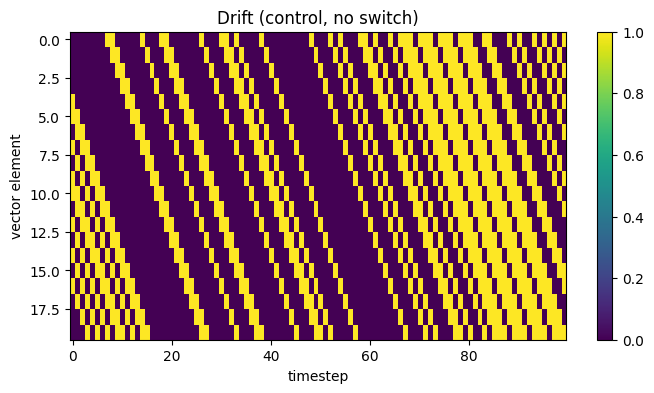

In [2]:
task = DriftTask(vector_length=VECTOR_LENGTH, prob=PROB)
data = task.generate(num_steps=NUM_STEPS, seed=SEED)
plot_task(data, 'Drift (control, no switch)')

## Test conditions (switch at the halfway point)

Each starts as ordinary rightward drift, then at the dashed line the condition
takes over. Using the same `seed`, the first half is identical across all three;
only the second half differs.


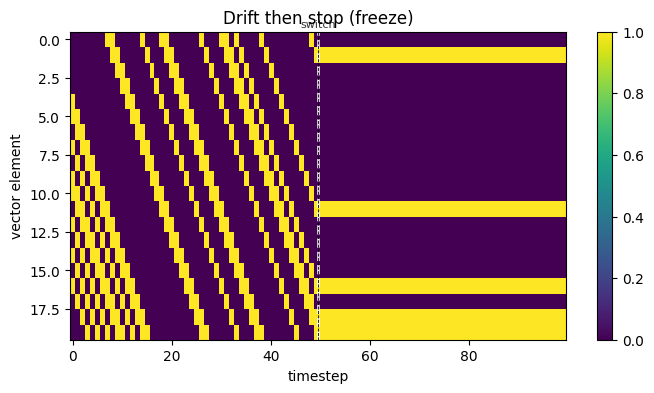

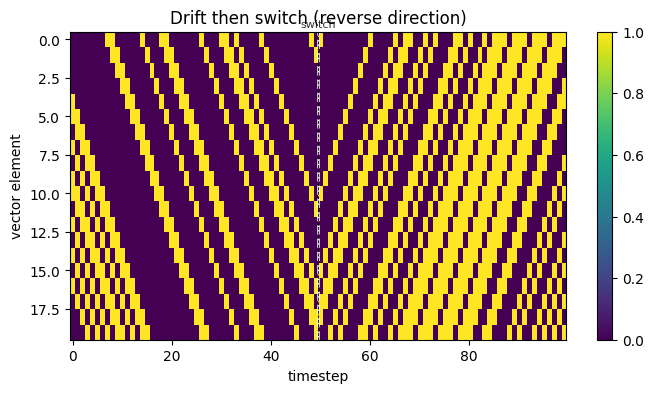

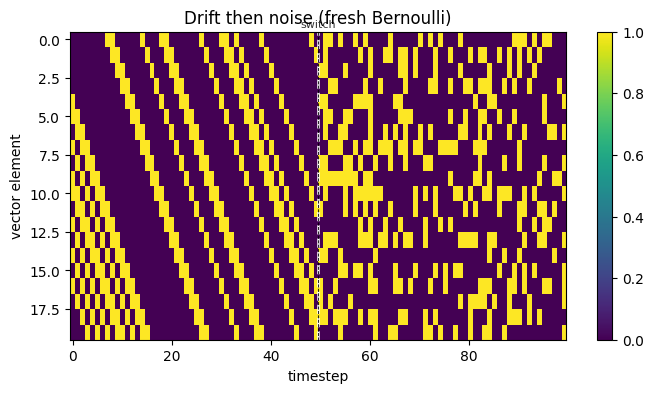

In [3]:
for condition, label in [(STOP, 'stop (freeze)'),
                         (SWITCH, 'switch (reverse direction)'),
                         (NOISE, 'noise (fresh Bernoulli)')]:
    task = DriftTask(vector_length=VECTOR_LENGTH, prob=PROB,
                     condition=condition, switch_step=SWITCH_STEP)
    data = task.generate(num_steps=NUM_STEPS, seed=SEED)
    plot_task(data, f'Drift then {label}', switch_step=SWITCH_STEP)

### Side by side

All conditions stacked, sharing the timestep axis, for easy comparison.

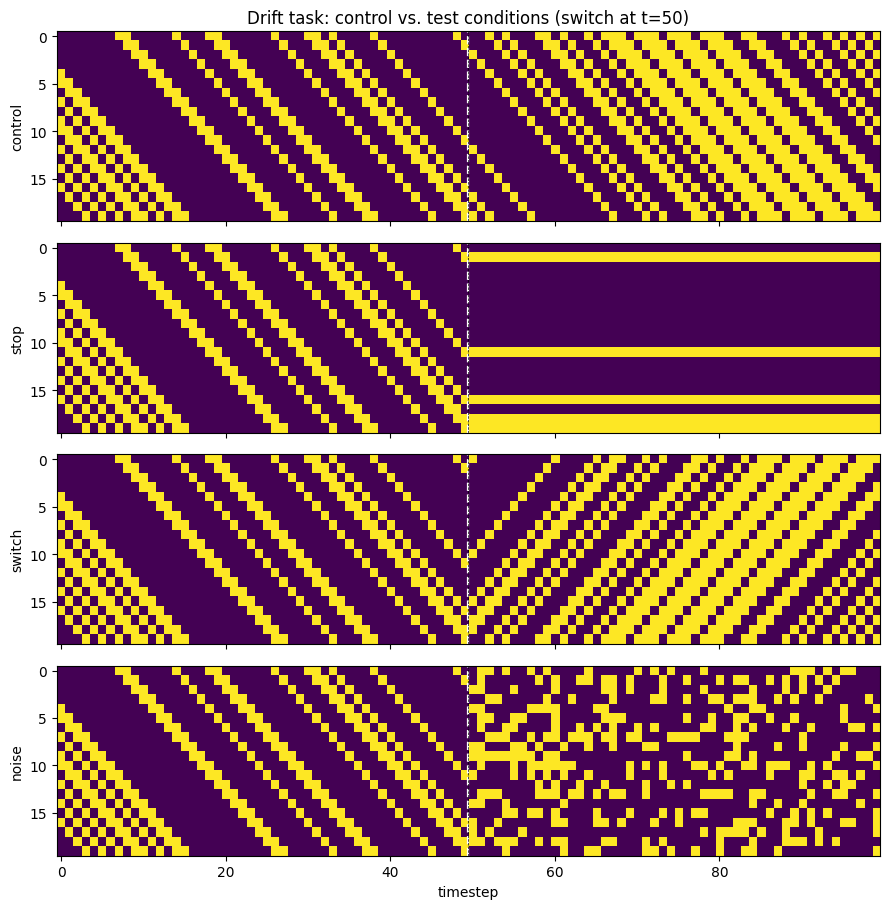

In [4]:
conditions = [(None, 'control'), (STOP, 'stop'), (SWITCH, 'switch'), (NOISE, 'noise')]
fig, axes = plt.subplots(len(conditions), 1, figsize=(9, 2.3 * len(conditions)), sharex=True)
for ax, (condition, label) in zip(axes, conditions):
    task = DriftTask(vector_length=VECTOR_LENGTH, prob=PROB,
                     condition=condition, switch_step=SWITCH_STEP)
    data = task.generate(num_steps=NUM_STEPS, seed=SEED)
    ax.imshow(data.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    ax.axvline(SWITCH_STEP - 0.5, color='w', lw=1.6, ls='--')
    ax.axvline(SWITCH_STEP - 0.5, color='k', lw=0.5, ls='--')
    ax.set_ylabel(label)
axes[-1].set_xlabel('timestep')
axes[0].set_title(f'Drift task: control vs. test conditions (switch at t={SWITCH_STEP})')
plt.tight_layout()
plt.show()